# GARCH 분석 수정본
## Student-t GARCH(1,1)-X 변동성 분석

루트 `GARCH_분석.ipynb` 기반 수정본
회의 후 수정사항 반영 버전

핵심 수정

1. **데이터 기준 변경**: 2019-01-01 ~ 2026-04-03
2. **이벤트명 통일**: `russia_ukraine_war`, `israel_hamas_war` 사용
3. **모형 구조 변경**: 외생변수는 평균방정식 X, 조건부 변동성 방정식에 투입
4. **분포 가정 변경**: 정규분포 X, Student-t likelihood 사용
5. **bounds 안정화**: `omega >= 0.05`, `alpha >= 0.01`
6. **Model2 multi-start**: 6개 초기값 실행 후 LogLik 최대 결과 선택
7. **조건부 변동성 재구성**: `.conditional_volatility` X, `reconstruct_cond_vol()` 사용

---
## Step 0. 라이브러리 및 경로 설정

수정본 기준

- `arch_model(...).fit()` 결과 객체 사용 안 함
- `.conditional_volatility`, `.params`, `.pvalues` 의존 안 함
- `scipy.optimize.minimize` 결과 직접 사용
- 실행 위치 자동 탐색
  - 루트에서 실행 가능
  - `minjin/` 안에서 실행 가능

In [20]:
import os
import platform
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import gammaln
from scipy.stats import t as t_dist

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

# 프로젝트 루트 자동 탐색
cwd = Path.cwd().resolve()
PROJECT_ROOT = None
for cand in [cwd, *cwd.parents]:
    if (cand / 'edit_mj').exists():
        PROJECT_ROOT = cand
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('프로젝트 루트를 찾지 못했습니다. edit_mj 폴더가 있는 위치에서 실행해주세요.')

DATA_PATH = PROJECT_ROOT / 'edit_mj' / 'GPR_맞춤분석' / '마스터 데이터 생성' / 'master_data (1).csv'
OUTPUT_DIR = PROJECT_ROOT / 'minjin' / 'garch_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('✅ 환경 설정 완료')
print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_PATH   : {DATA_PATH}')
print(f'OUTPUT_DIR  : {OUTPUT_DIR}')

✅ 환경 설정 완료
PROJECT_ROOT: /Users/minjin/cs_mj
DATA_PATH   : /Users/minjin/cs_mj/edit_mj/GPR_맞춤분석/마스터 데이터 생성/master_data (1).csv
OUTPUT_DIR  : /Users/minjin/cs_mj/minjin/garch_outputs


---
## Step 1. 이벤트 및 모델 정의

새 master data 기준 이벤트명

- `russia_ukraine_war`
- `israel_hamas_war`

기존 이름 사용 안 함

- `russia_ukraine_invasion`
- `israel_hamas`

체크 포인트

- `master['event_name'].unique()`
- `EVENT_DATES.keys()`

둘이 정확히 일치해야 정렬/필터링/시각화 정상 작동

모델은 회의 메모 기준 5개 사용

In [21]:
EVENT_DATES = {
    'hormuz_crisis'          : '2019-06-13',
    'soleimani_assassination': '2020-01-03',
    'russia_ukraine_war'    : '2022-02-24',
    'israel_hamas_war'      : '2023-10-07',
    'israel_iran'           : '2024-04-01',
    'us_israel_iran'        : '2026-02-28',
}

EVENT_LABELS = {
    'hormuz_crisis'          : '호르무즈 위기',
    'soleimani_assassination': '솔레이마니 암살',
    'russia_ukraine_war'    : '러-우 전쟁',
    'israel_hamas_war'      : '이스라엘-하마스 전쟁',
    'israel_iran'           : '이스라엘-이란 충돌',
    'us_israel_iran'        : '이란 전쟁',
}

MODEL_EXOG = {
    'Model1': ['GPR_zscore_scaled'],
    'Model2': ['GPR_custom_scaled'],
    'Model3': ['VIX_scaled', 'fear_greed_lag1_scaled'],
    'Model4': ['GPR_zscore_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'],
    'Model5': ['GPR_custom_scaled', 'VIX_scaled', 'fear_greed_lag1_scaled'],
}

MODEL_LABELS = {
    'Model1': '공식 GPR 단독',
    'Model2': '커스텀 GPR 단독',
    'Model3': 'VIX + Fear&Greed',
    'Model4': '공식 GPR + 시장심리',
    'Model5': '커스텀 GPR + 시장심리',
}

MODEL_COLORS = {
    'Model1': '#E76F51',
    'Model2': '#2A9D8F',
    'Model3': '#457B9D',
    'Model4': '#8338EC',
    'Model5': '#F4A261',
}

print('✅ 이벤트/모델 정의 완료')

✅ 이벤트/모델 정의 완료


---
## Step 2. 수정 master data 로드

루트 `master_data.csv` 사용 안 함
수정 데이터 사용

```text
edit_mj/GPR_맞춤분석/마스터 데이터 생성/master_data (1).csv
```

분석 대상 조건

- `BTC` 존재
- `GPR_custom` 존재
- `GPR_zscore` 존재
- `VIX` 존재
- `fear_greed_lag1` 존재

위 컬럼 결측 없는 거래일만 사용

In [22]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f'수정 master data 파일이 없습니다: {DATA_PATH}')

master = pd.read_csv(DATA_PATH)
master['date'] = pd.to_datetime(master['date'])
master['event_date'] = pd.to_datetime(master['event_date'])

num_cols = ['GPR_custom', 'F3_raw', 'GPR', 'GPR_zscore', 'N', 'mean_tone',
            'BTC', 'Gold', 'TLT', 'DXY', 'SP500', 'NASDAQ', 'VIX',
            'fear_greed', 'fear_greed_lag1']
for col in num_cols:
    if col in master.columns:
        master[col] = pd.to_numeric(master[col], errors='coerce')

print(f'✅ master 로드: {len(master)}행')
print(f'기간: {master["date"].min().date()} ~ {master["date"].max().date()}')
print('\n이벤트명 확인:')
print(master['event_name'].value_counts().sort_index().to_string())

missing_events = sorted(set(EVENT_DATES) - set(master['event_name'].dropna().unique()))
extra_events = sorted(set(master['event_name'].dropna().unique()) - set(EVENT_DATES))
if missing_events or extra_events:
    print('\n⚠️ 이벤트명 불일치 확인 필요')
    print('EVENT_DATES에는 있으나 데이터에 없는 이벤트:', missing_events)
    print('데이터에는 있으나 EVENT_DATES에 없는 이벤트:', extra_events)
else:
    print('\n✅ EVENT_DATES와 데이터 event_name 일치')

✅ master 로드: 1827행
기간: 2019-01-02 ~ 2026-04-30

이벤트명 확인:
event_name
hormuz_crisis              182
israel_hamas_war           260
israel_iran                299
russia_ukraine_war         475
soleimani_assassination    339
us_israel_iran             272

✅ EVENT_DATES와 데이터 event_name 일치


---
## Step 3. 분석 데이터 준비

### 처리 요약

| 항목 | 처리 | 이유 |
|---|---|---|
| 종속변수 | `returns_pct = BTC * 100` | GARCH 수렴 안정화 |
| 외생변수 | `master_final` 기준 z-score 표준화 | 변수 단위 통일 |
| 시차 | `X_{t-1}` 사용 | 어제 지표가 오늘 변동성에 미치는 효과 |
| 결측 | `BTC`, 외생변수 결측 제거 | 실제 관측치 기준 분석 |

### 표준화

```text
X_scaled = (X - mean(X)) / std(X)
```

| 표준화 이유 | 설명 |
|---|---|
| 단위 통일 | `GPR_custom`, `GPR_zscore`, `VIX`, `fear_greed_lag1` 단위 다름 |
| gamma 비교 | 표준화 후 “1표준편차 증가 효과”로 해석 가능 |
| 최적화 안정성 | 큰 스케일 변수에 optimizer가 끌리는 문제 완화 |

### 점검 기준

| 출력값 | 정상 기준 |
|---|---|
| `mean` | 0 근처 |
| `std` | 1 근처 |
| `-0.0000`, `1.0000` | 반올림 결과라 정상 |

### 주의

- 전체 pooled GARCH-X 목적이라 전체 표본 기준 표준화 사용
- 이벤트별 표준화는 이벤트 간 비교 어려움
- 새 변수 추가 시 `exog_cols_all`, `MODEL_EXOG` 같이 확인 필요

### 변동성 방정식

```text
h_t = omega + alpha * epsilon_{t-1}^2 + beta * h_{t-1} + gamma * X_{t-1}
```

In [23]:
# 이벤트 순서 정렬
order = list(EVENT_DATES.keys())
master['_order'] = master['event_name'].map({ev: i for i, ev in enumerate(order)})
master_sorted = master.sort_values(['_order', 'date']).reset_index(drop=True)

# 분석에 필요한 컬럼만 결측치 제거
exog_cols_all = ['GPR_custom', 'GPR_zscore', 'VIX', 'fear_greed_lag1']
required_cols = ['BTC'] + exog_cols_all
master_final = master_sorted.dropna(subset=required_cols).copy().reset_index(drop=True)

# 수익률 스케일 조정
master_final['returns_pct'] = master_final['BTC'] * 100

# 외생변수 표준화
for col in exog_cols_all:
    mu, sig = master_final[col].mean(), master_final[col].std()
    master_final[f'{col}_scaled'] = (master_final[col] - mu) / sig if sig > 0 else 0.0

final_returns = master_final['returns_pct']
final_exog = master_final[[f'{col}_scaled' for col in exog_cols_all]]

print(f'✅ 분석 대상: {len(master_final)}거래일')
print('\n이벤트별 분석 대상 거래일:')
print(master_final.groupby('event_name')['date'].count().to_string())
print('\nBTC 수익률 ×100 기술통계:')
print(final_returns.describe().round(4).to_string())
print('\n외생변수 표준화 점검:')
print(final_exog.describe().loc[['mean', 'std']].round(4).to_string())

✅ 분석 대상: 1821거래일

이벤트별 분석 대상 거래일:
event_name
hormuz_crisis              181
israel_hamas_war           259
israel_iran                298
russia_ukraine_war         474
soleimani_assassination    338
us_israel_iran             271

BTC 수익률 ×100 기술통계:
count    1821.0000
mean        0.1693
std         3.9545
min       -46.4730
25%        -1.6010
50%         0.0916
75%         1.9607
max        20.3046

외생변수 표준화 점검:
      GPR_custom_scaled  GPR_zscore_scaled  VIX_scaled  fear_greed_lag1_scaled
mean               -0.0                0.0         0.0                     0.0
std                 1.0                1.0         1.0                     1.0


---
## Step 4. Student-t GARCH-X 직접 MLE 함수

### 처리 방식

| 구분 | 방식 | 용도 |
|---|---|---|
| 기본 | `variance_mode='clip'` | 회의 메모/`edit_mj` 수정본 재현 |
| 추가 확인 | `variance_mode='strict'` | 양수분산 조건 강건성 확인 |

| 방식 | `h_t <= 1e-8` 발생 시 처리 |
|---|---|
| `clip` | `h_t = 1e-8`로 보정 |
| `strict` | 해당 후보 탈락 처리 |

### 평균방정식

```text
y_t = mu + e_t
```

| 기호 | 의미 |
|---|---|
| `y_t` | BTC 수익률 × 100 |
| `mu` | 평균 수익률 수준 |
| `e_t` | 평균으로 설명되지 않는 충격 |

### 변동성방정식

```text
h_t = omega + alpha * e_{t-1}^2 + beta * h_{t-1} + gamma'X_{t-1}
```

| 기호 | 의미 | 해석 |
|---|---|---|
| `h_t` | 조건부 분산 | 오늘 변동성 수준 |
| `omega` | 기본 변동성 | 상수항 |
| `alpha` | 충격 반응 | 어제 충격이 오늘 변동성에 미치는 영향 |
| `beta` | 지속성 | 변동성이 얼마나 오래 이어지는지 |
| `X_{t-1}` | 외생변수 | 어제 GPR/VIX/Fear&Greed |
| `gamma` | 외생변수 효과 | 양수면 변동성 증가, 음수면 감소 |

### Student-t 오차항

```text
e_t / sqrt(h_t) ~ standardized Student-t(nu)
```

| 항목 | 의미 |
|---|---|
| Student-t | 정규분포보다 두꺼운 꼬리 반영 |
| `nu` | 자유도, 작을수록 fat-tail 강함 |
| 사용 이유 | BTC 극단 수익률 반영 |

### bounds

| 파라미터 | 제약 | 목적 |
|---|---|---|
| `omega` | `>= 0.05` | 0 수렴 방지 |
| `alpha` | `0.01 ~ 0.5` | 가짜 t-stat/0 수렴 완화 |
| `beta` | `0.3 ~ 0.999` | 지속성 범위 제한 |
| `nu` | `2.01 ~ 50` | Student-t 분산 존재 조건 |

In [ ]:
def student_t_neg_loglik(params, y_vals, X_lag, variance_mode='clip'):
    """
    Student-t GARCH-X negative log-likelihood.

    variance_mode='clip'
        h_t <= 1e-8이면 1e-8로 보정
        기존 수정본 재현용 기본값

    variance_mode='strict'
        h_t <= 1e-8이면 큰 penalty 반환
        양수분산 조건 강건성 확인용
    """
    T = len(y_vals)
    K = X_lag.shape[1]

    mu = params[0]
    omega = params[1]
    alpha = params[2]
    beta = params[3]
    gamma = params[4:4+K]
    nu = params[4+K]

    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 0.9999 or nu <= 2.01:
        return 1e10

    e = y_vals - mu
    h = np.empty(T)
    h[0] = max(np.var(e), 1e-8)

    for t in range(1, T):
        exog_effect = np.dot(gamma, X_lag[t])
        h[t] = omega + alpha * e[t-1]**2 + beta * h[t-1] + exog_effect
        if h[t] <= 1e-8 or not np.isfinite(h[t]):
            if variance_mode == 'clip':
                h[t] = 1e-8
            elif variance_mode == 'strict':
                return 1e10
            else:
                raise ValueError("variance_mode must be 'clip' or 'strict'")

    log_lik = (
        gammaln((nu + 1) / 2)
        - gammaln(nu / 2)
        - 0.5 * np.log(np.pi * (nu - 2))
        - 0.5 * np.log(h)
        - ((nu + 1) / 2) * np.log(1 + e**2 / ((nu - 2) * h))
    )

    if not np.all(np.isfinite(log_lik)):
        return 1e10
    return -np.sum(log_lik)


def make_initial_params(y_vals, K, alpha0=0.08, beta0=0.88):
    return np.array([
        np.mean(y_vals),
        max(np.var(y_vals) * 0.05, 0.05),
        alpha0,
        beta0,
        *([0.001] * K),
        5.0,
    ], dtype=float)


def garch_bounds(K):
    return (
        [(None, None)]
        + [(0.05, None)]
        + [(0.01, 0.5)]
        + [(0.3, 0.999)]
        + [(None, None)] * K
        + [(2.01, 50.0)]
    )


def fit_garch_x_model(y_series, exog_df, model_exog_cols, model_name='Model', variance_mode='clip', verbose=True):
    y = y_series.dropna().astype(float)
    actual_cols = [c for c in model_exog_cols if c in exog_df.columns]
    if not actual_cols:
        return {'result': None, 'error': f'사용 가능한 외생변수 없음: {model_exog_cols}'}

    X_raw = exog_df.loc[y.index, actual_cols].astype(float).ffill().fillna(0.0)
    X_lag = X_raw.shift(1).fillna(0.0).values
    y_vals = y.values
    T = len(y_vals)
    K = len(actual_cols)

    if model_name == 'Model2':
        start_grid = [(0.05, 0.90), (0.08, 0.88), (0.10, 0.85),
                      (0.05, 0.80), (0.15, 0.75), (0.10, 0.95)]
    else:
        start_grid = [(0.08, 0.88)]

    tried = []
    best = None
    if verbose:
        print(f'\n[{model_name}] 사용 외생변수: {actual_cols}')
        print(f'분산 처리 방식: {variance_mode}')
        if model_name == 'Model2':
            print('[Model2] multi-start 실행')

    for alpha0, beta0 in start_grid:
        init = make_initial_params(y_vals, K, alpha0=alpha0, beta0=beta0)
        obj = lambda p: student_t_neg_loglik(p, y_vals, X_lag, variance_mode=variance_mode)
        opt = minimize(
            obj,
            init,
            method='L-BFGS-B',
            bounds=garch_bounds(K),
            options={'maxiter': 5000, 'ftol': 1e-14, 'gtol': 1e-8},
        )
        loglik = -opt.fun if np.isfinite(opt.fun) else -np.inf
        tried.append({'alpha0': alpha0, 'beta0': beta0, 'loglik': loglik, 'success': opt.success})
        if verbose and model_name == 'Model2':
            print(f'  alpha0={alpha0:<4} beta0={beta0:<4} → LogLik={loglik:.3f}')
        if best is None or loglik > best['loglik']:
            best = {'opt': opt, 'loglik': loglik, 'neg_loglik': obj}

    opt = best['opt']
    loglik = best['loglik']
    p = opt.x
    n_params = len(p)
    aic = -2 * loglik + 2 * n_params
    bic = -2 * loglik + n_params * np.log(T)
    param_names = ['mu', 'omega', 'alpha', 'beta'] + [f'gamma({c})' for c in actual_cols] + ['nu']

    if verbose and model_name == 'Model2':
        print(f'✅ [Model2] 최종 선택 LogLik={loglik:.3f}')

    return {
        'result': opt,
        'params': dict(zip(param_names, p)),
        'param_names': param_names,
        'exog_cols': actual_cols,
        'aic': aic,
        'bic': bic,
        'loglik': loglik,
        'converged': opt.success,
        'error': None,
        'T': T,
        'K': K,
        'y_index': y.index,
        'X_lag': X_lag,
        'y_vals': y_vals,
        'neg_loglik': best['neg_loglik'],
        'starts': tried,
        'variance_mode': variance_mode,
    }

print('✅ GARCH-X 직접 MLE 함수 정의 완료')

✅ GARCH-X 직접 MLE 함수 정의 완료


---
## Step 5. Model1~Model5 추정

Model2 처리

- `GPR_custom` 단독 모델
- 회의 메모 기준 multi-start 적용
- 6개 초기값 실행
- LogLik 최대 결과 선택

비교 기준

- `LogLik`: 높을수록 좋음
- `AIC/BIC`: 낮을수록 좋음

In [25]:
garch_results = {}

print('=' * 80)
print('▶ GARCH(1,1)-X 변동성 분석 (직접 MLE | Student-t | t-1 외생변수)')
print('=' * 80)

for mname, exog_cols in MODEL_EXOG.items():
    res = fit_garch_x_model(final_returns, master_final, exog_cols, model_name=mname)
    garch_results[mname] = res
    if res.get('error'):
        print(f'[{mname}] 오류: {res["error"]}')
        continue

    print(f'\n  ── [{mname}] 추정 결과: {MODEL_LABELS[mname]} ──')
    for pname, val in res['params'].items():
        print(f'  {pname:<32} {val:>12.5f}')
    p = res['result'].x
    print(f'  LogLikelihood : {res["loglik"]:.4f}')
    print(f'  AIC           : {res["aic"]:.4f}')
    print(f'  BIC           : {res["bic"]:.4f}')
    print(f'  수렴 여부     : {"성공" if res["converged"] else "미수렴"}')
    print(f'  alpha+beta    : {p[2] + p[3]:.4f}')

▶ GARCH(1,1)-X 변동성 분석 (직접 MLE | Student-t | t-1 외생변수)

[Model1] 사용 외생변수: ['GPR_zscore_scaled']
분산 처리 방식: clip

  ── [Model1] 추정 결과: 공식 GPR 단독 ──
  mu                                    0.08879
  omega                                 0.44149
  alpha                                 0.08076
  beta                                  0.91295
  gamma(GPR_zscore_scaled)             -0.00450
  nu                                    2.99912
  LogLikelihood : -4785.2587
  AIC           : 9582.5174
  BIC           : 9615.5602
  수렴 여부     : 성공
  alpha+beta    : 0.9937

[Model2] 사용 외생변수: ['GPR_custom_scaled']
분산 처리 방식: clip
[Model2] multi-start 실행
  alpha0=0.05 beta0=0.9  → LogLik=-4785.201
  alpha0=0.08 beta0=0.88 → LogLik=-4785.201
  alpha0=0.1  beta0=0.85 → LogLik=-4785.201
  alpha0=0.05 beta0=0.8  → LogLik=-4785.201
  alpha0=0.15 beta0=0.75 → LogLik=-4785.201
  alpha0=0.1  beta0=0.95 → LogLik=-10000000000.000
✅ [Model2] 최종 선택 LogLik=-4785.201

  ── [Model2] 추정 결과: 커스텀 GPR 단독 ──
  mu               

---
## Step 6. 표준오차, t-stat, p-value 계산

직접 MLE라서 자동 p-value 없음
Hessian 수치 근사로 계산

주의

- p-value는 보조 기준
- GARCH likelihood 복잡함
- Hessian 역행렬 불안정 가능
- 해석 시 AIC/BIC, 계수 방향, 표본 수 한계 같이 확인

In [26]:
def compute_pvalues(opt_result, neg_loglik_func, param_names, T):
    params = opt_result.x
    n_params = len(params)
    eps = 1e-5
    H = np.zeros((n_params, n_params))

    for i in range(n_params):
        for j in range(n_params):
            p_pp = params.copy(); p_pp[i] += eps; p_pp[j] += eps
            p_pm = params.copy(); p_pm[i] += eps; p_pm[j] -= eps
            p_mp = params.copy(); p_mp[i] -= eps; p_mp[j] += eps
            p_mm = params.copy(); p_mm[i] -= eps; p_mm[j] -= eps
            H[i, j] = (neg_loglik_func(p_pp) - neg_loglik_func(p_pm)
                       - neg_loglik_func(p_mp) + neg_loglik_func(p_mm)) / (4 * eps**2)

    try:
        cov = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        print('  ⚠️ Hessian 역행렬 실패 → 유사역행렬 사용')
        cov = np.linalg.pinv(H)

    se = np.sqrt(np.abs(np.diag(cov)))
    t_stats = params / se
    df = max(T - n_params, 1)
    p_values = 2 * (1 - t_dist.cdf(np.abs(t_stats), df=df))

    return {
        'se': se,
        't_stats': t_stats,
        'p_values': p_values,
        'cov_mat': cov,
    }

for mname, res in garch_results.items():
    if res.get('error') or res.get('result') is None:
        continue
    print(f'\n{"="*72}')
    print(f'[{mname}] p-value 계산')
    print(f'{"="*72}')
    stat = compute_pvalues(res['result'], res['neg_loglik'], res['param_names'], res['T'])
    garch_results[mname]['stats'] = stat
    print(f'  {"파라미터":<32} {"추정값":>10} {"SE":>10} {"t-stat":>10} {"p-value":>10}')
    print('  ' + '-' * 78)
    for pname, val, se, tval, pv in zip(res['param_names'], res['result'].x, stat['se'], stat['t_stats'], stat['p_values']):
        sig = '***' if pv < 0.01 else '**' if pv < 0.05 else '*' if pv < 0.10 else ''
        print(f'  {pname:<32} {val:>10.4f} {se:>10.4f} {tval:>10.3f} {pv:>10.4f} {sig}')


[Model1] p-value 계산
  파라미터                                    추정값         SE     t-stat    p-value
  ------------------------------------------------------------------------------
  mu                                   0.0888     0.0634      1.399     0.1619 
  omega                                0.4415     0.1685      2.620     0.0089 ***
  alpha                                0.0808     0.0200      4.048     0.0001 ***
  beta                                 0.9129     0.0181     50.488     0.0000 ***
  gamma(GPR_zscore_scaled)            -0.0045     0.0902     -0.050     0.9602 
  nu                                   2.9991     0.2540     11.806     0.0000 ***

[Model2] p-value 계산
  파라미터                                    추정값         SE     t-stat    p-value
  ------------------------------------------------------------------------------
  mu                                   0.0886     0.0634      1.398     0.1624 
  omega                                0.4432     0.1675      2.64

---
## Step 7. 외생변수 γ 계수 요약

`gamma` 의미

- 외생변수가 BTC 조건부 변동성에 미치는 방향

해석

- `gamma > 0`: 외생변수 증가 시 BTC 변동성 증가
- `gamma < 0`: 외생변수 증가 시 BTC 변동성 감소
- p-value 작을수록 통계적 근거 강함

사용 기준

- `res['param_names']`
- `res['result'].x`
- `res['stats']['p_values']`

사용 안 함

- `r.params.index`
- `r.pvalues`

In [27]:
gamma_rows = []
print('▶ 외생변수 γ 계수 요약')
print(f'{"모델":<8} {"변수":<30} {"γ":>10} {"p-value":>10} {"판정":<12} {"해석"}')
print('-' * 92)

for mname, res in garch_results.items():
    if res.get('error') or res.get('result') is None:
        continue
    p_values = res.get('stats', {}).get('p_values')
    if p_values is None:
        continue
    for i, pname in enumerate(res['param_names']):
        if not pname.startswith('gamma('):
            continue
        vname = pname[6:-1]
        coef = res['result'].x[i]
        pv = p_values[i]
        sig = 'p<0.05' if pv < 0.05 else 'p<0.10' if pv < 0.10 else '비유의'
        interp = '변동성 증가' if coef > 0 else '변동성 감소'
        print(f'{mname:<8} {vname:<30} {coef:>10.5f} {pv:>10.4f} {sig:<12} {interp}')
        gamma_rows.append({
            'model': mname,
            'model_label': MODEL_LABELS.get(mname, mname),
            'variable': vname,
            'gamma': coef,
            'p_value': pv,
            'significance': sig,
            'interpretation': interp,
        })

gamma_df = pd.DataFrame(gamma_rows)
display(gamma_df)

▶ 외생변수 γ 계수 요약
모델       변수                                      γ    p-value 판정           해석
--------------------------------------------------------------------------------------------
Model1   GPR_zscore_scaled                -0.00450     0.9602 비유의          변동성 감소
Model2   GPR_custom_scaled                 0.02627     0.7346 비유의          변동성 증가
Model3   VIX_scaled                       -0.02308     0.8008 비유의          변동성 감소
Model3   fear_greed_lag1_scaled            0.15725     0.0375 p<0.05       변동성 증가
Model4   GPR_zscore_scaled                 0.00671     0.9258 비유의          변동성 증가
Model4   VIX_scaled                       -0.03400     0.6997 비유의          변동성 감소
Model4   fear_greed_lag1_scaled            0.17472     0.0291 p<0.05       변동성 증가
Model5   GPR_custom_scaled                 0.03637     0.5962 비유의          변동성 증가
Model5   VIX_scaled                       -0.02472     0.7875 비유의          변동성 감소
Model5   fear_greed_lag1_scaled            0.16153     0.0339 p<0.05       변

,model,model_label,variable,gamma,p_value,significance,interpretation
0,Model1,공식 GPR 단독,GPR_zscore_scaled,-0.004497,0.960241,비유의,변동성 감소
1,Model2,커스텀 GPR 단독,GPR_custom_scaled,0.026273,0.734627,비유의,변동성 증가
2,Model3,VIX + Fear&Greed,VIX_scaled,-0.023083,0.800763,비유의,변동성 감소
3,Model3,VIX + Fear&Greed,fear_greed_lag1_scaled,0.157250,0.037528,p<0.05,변동성 증가
4,Model4,공식 GPR + 시장심리,GPR_zscore_scaled,0.006712,0.925773,비유의,변동성 증가
5,Model4,공식 GPR + 시장심리,VIX_scaled,-0.034003,0.699696,비유의,변동성 감소
6,Model4,공식 GPR + 시장심리,fear_greed_lag1_scaled,0.174720,0.029146,p<0.05,변동성 증가
7,Model5,커스텀 GPR + 시장심리,GPR_custom_scaled,0.036367,0.596209,비유의,변동성 증가
8,Model5,커스텀 GPR + 시장심리,VIX_scaled,-0.024716,0.787510,비유의,변동성 감소
9,Model5,커스텀 GPR + 시장심리,fear_greed_lag1_scaled,0.161534,0.033936,p<0.05,변동성 증가


---
## Step 8. 모델 비교

AIC/BIC 용도

- 외생변수 조합별 상대 적합도 비교
- 낮을수록 좋은 모델

주의

- AIC 최저 = 경제적 결론 확정 아님
- 표본 수 한계 있음
- 이벤트 중첩 가능성 있음
- `GPR_custom` 구성 방식 한계 있음

In [28]:
rows = []
for mname, res in garch_results.items():
    if res.get('error') or res.get('aic') is None:
        continue
    rows.append({
        'model': mname,
        'description': MODEL_LABELS.get(mname, mname),
        'exog': ', '.join(res['exog_cols']),
        'loglik': res['loglik'],
        'AIC': res['aic'],
        'BIC': res['bic'],
        'converged': res['converged'],
        'alpha+beta': res['result'].x[2] + res['result'].x[3],
    })

compare_df = pd.DataFrame(rows).sort_values('AIC').reset_index(drop=True)
display(compare_df.round({'loglik': 3, 'AIC': 3, 'BIC': 3, 'alpha+beta': 4}))

if len(compare_df) > 0:
    best_model = compare_df.iloc[0]['model']
    print(f'✅ AIC 기준 최적 모델: {best_model} ({MODEL_LABELS[best_model]})')

,model,description,exog,loglik,AIC,BIC,converged,alpha+beta
0,Model3,VIX + Fear&Greed,"VIX_scaled, fear_greed_lag1_scaled",-4782.355,9578.710,9617.260,True,0.9961
1,Model5,커스텀 GPR + 시장심리,"GPR_custom_scaled, VIX_scaled, fear_greed_lag1...",-4782.208,9580.417,9624.474,True,0.9960
2,Model4,공식 GPR + 시장심리,"GPR_zscore_scaled, VIX_scaled, fear_greed_lag1...",-4782.403,9580.805,9624.862,True,0.9999
3,Model2,커스텀 GPR 단독,GPR_custom_scaled,-4785.201,9582.402,9615.445,True,0.9937
4,Model1,공식 GPR 단독,GPR_zscore_scaled,-4785.259,9582.517,9615.560,True,0.9937


✅ AIC 기준 최적 모델: Model3 (VIX + Fear&Greed)


---
## Step 8-1. 분산 처리 방식 확인

기본 결과

- `variance_mode='clip'`
- `h_t <= 1e-8`이면 `1e-8`로 클리핑
- 회의 메모/`edit_mj` 수정본 재현용

추가 확인

- `variance_mode='strict'`
- `h_t <= 1e-8`이면 해당 후보 탈락
- 조건부 분산 양수 조건을 더 엄격하게 본 방식

확인 목적

- 최적 모델이 처리 방식에 민감한지 확인
- `clip`과 `strict` 최적 모델이 같으면 비교적 안정적
- `clip`과 `strict` 최적 모델이 다르면 분산 처리 방식에 민감한 결과

현재 결과 해석

- 최적모형이 동일하면 기본 결과 신뢰도 보강 근거로 사용 가능
- 그래도 AIC 차이, gamma 방향, alpha+beta는 같이 확인 필요

In [36]:
strict_results = {}
print('=' * 80)
print('▶strict variance mode')
print('=' * 80)

for mname, exog_cols in MODEL_EXOG.items():
    res = fit_garch_x_model(
        final_returns,
        master_final,
        exog_cols,
        model_name=mname,
        variance_mode='strict',
        verbose=False,
    )
    strict_results[mname] = res

strict_rows = []
for mname, res in strict_results.items():
    if res.get('error') or res.get('aic') is None:
        continue
    strict_rows.append({
        'model': mname,
        'description': MODEL_LABELS.get(mname, mname),
        'loglik_strict': res['loglik'],
        'AIC_strict': res['aic'],
        'BIC_strict': res['bic'],
        'alpha+beta_strict': res['result'].x[2] + res['result'].x[3],
        'converged_strict': res['converged'],
    })

strict_compare_df = pd.DataFrame(strict_rows).sort_values('AIC_strict').reset_index(drop=True)

aic_compare = compare_df[['model', 'description', 'AIC', 'BIC', 'loglik', 'alpha+beta']].merge(
    strict_compare_df[['model', 'AIC_strict', 'BIC_strict', 'loglik_strict', 'alpha+beta_strict']],
    on='model',
    how='left'
)
aic_compare['AIC_change_strict_minus_clip'] = aic_compare['AIC_strict'] - aic_compare['AIC']

display(aic_compare.round(3))

best_clip = compare_df.iloc[0]['model'] if len(compare_df) else None
best_strict = strict_compare_df.iloc[0]['model'] if len(strict_compare_df) else None
print(f'clip 기준 최적 모델   : {best_clip}')
print(f'strict 기준 최적 모델 : {best_strict}')

if best_clip != best_strict:
    print('⚠️ 최적 모델 변경됨 → 분산 처리 방식에 민감한 결과')
else:
    print('✅ 최적 모델 동일 → 분산 처리 방식에 비교적 안정적')

▶strict variance mode


,model,description,AIC,BIC,loglik,alpha+beta,AIC_strict,BIC_strict,loglik_strict,alpha+beta_strict,AIC_change_strict_minus_clip
0,Model3,VIX + Fear&Greed,9578.710,9617.260,-4782.355,0.996,9578.710,9617.260,-4782.355,0.996,-0.000
1,Model5,커스텀 GPR + 시장심리,9580.417,9624.474,-4782.208,0.996,9580.462,9624.520,-4782.231,0.996,0.046
2,Model4,공식 GPR + 시장심리,9580.805,9624.862,-4782.403,1.000,9580.390,9624.447,-4782.195,0.997,-0.415
3,Model2,커스텀 GPR 단독,9582.402,9615.445,-4785.201,0.994,9582.402,9615.445,-4785.201,0.994,0.000
4,Model1,공식 GPR 단독,9582.517,9615.560,-4785.259,0.994,9582.517,9615.560,-4785.259,0.994,-0.000


clip 기준 최적 모델   : Model3
strict 기준 최적 모델 : Model3
✅ 최적 모델 동일 → 분산 처리 방식에 비교적 안정적


---
## Step 8-2. 결과 해석 메모

### 핵심 결론

| 항목 | 기존 데이터 기준 | 현재 기준 |
|---|---:|---:|
| 최적 모델 | Model2 | Model3 |
| 기준 | 짧은 이벤트/부분 표본 | 전체 1821거래일 |
| clip 기준 | - | Model3 |
| strict 기준 | - | Model3 |
| 분산 처리 영향 | 확인 어려움 | 영향 아님 |

### 원인 1. 표본 크기 차이

| 구분 | AIC | LogLik | 의미 |
|---|---:|---:|---|
| 기존 결과 | 약 1087 | 약 -537 | 짧은 표본 기준 |
| 현재 결과 | 약 9578 | 약 -4782 | 전체 1821거래일 기준 |

- 같은 표본이면 AIC/LogLik 스케일이 이렇게 달라질 수 없음
- 기존 결과와 현재 결과 직접 비교 불가

### 원인 2. 현재 표본에서 Model2 설명력 약함

| 모델 | 변수 | gamma | p-value | 해석 |
|---|---|---:|---:|---|
| Model2 | `GPR_custom_scaled` | 0.0263 | 0.7346 | 비유의 |

- 방향은 양수
- 통계적으로는 설명력 약함
- 현재 전체 표본에서는 커스텀 GPR 단독 효과 약함

### 원인 3. Model3의 likelihood 개선폭이 AIC penalty 초과

| 모델 | LogLik | AIC | 핵심 변수 |
|---|---:|---:|---|
| Model2 | -4785.201 | 9582.402 | `GPR_custom_scaled` |
| Model3 | -4782.355 | 9578.710 | `VIX_scaled`, `fear_greed_lag1_scaled` |

AIC 계산

```text
AIC = -2 * LogLik + 2 * k
```

계산 포인트

| 항목 | 값 |
|---|---:|
| LogLik 개선폭 | `2.846` |
| 추가 파라미터 penalty | `2` |
| AIC 개선폭 | `3.692` |

결론

- Model3가 파라미터 1개 더 쓰지만 LogLik 개선폭이 더 큼
- 그래서 AIC 기준 Model3 최적

### 현재 해석

| 결과 | 해석 |
|---|---|
| Model3 최적 | 시장심리 변수 설명력 우세 |
| `fear_greed_lag1_scaled` 유의 | 전일 공포·탐욕 지수가 BTC 변동성에 영향 |
| `GPR_custom_scaled` 비유의 | 커스텀 GPR 단독 설명력 약함 |
| clip/strict 동일 | 분산 처리 방식에 민감하지 않음 |

---
## Step 9. 조건부 변동성 재구성

직접 MLE 결과 객체

```python
scipy.optimize.OptimizeResult
```

따라서 없음

```python
.conditional_volatility
```

대신 추정 파라미터로 직접 재계산

```text
sigma_t = sqrt(h_t)
```

`reconstruct_cond_vol()` 역할

- 저장된 `mu, omega, alpha, beta, gamma` 사용
- GARCH-X 방정식 반복 계산
- 조건부 변동성 `sigma_t` 반환

In [30]:
def reconstruct_cond_vol(res, y_series=None, exog_df=None):
    if y_series is None:
        y_vals = res['y_vals']
    else:
        y = y_series.loc[res['y_index']].astype(float)
        y_vals = y.values

    if exog_df is None:
        X_lag = res['X_lag']
    else:
        X_raw = exog_df.loc[res['y_index'], res['exog_cols']].astype(float).ffill().fillna(0.0)
        X_lag = X_raw.shift(1).fillna(0.0).values

    p = res['result'].x
    K = len(res['exog_cols'])
    mu, omega, alpha, beta = p[0], p[1], p[2], p[3]
    gamma = p[4:4+K]

    e = y_vals - mu
    h = np.empty(len(y_vals))
    h[0] = max(np.var(e), 1e-8)
    for t in range(1, len(y_vals)):
        h[t] = omega + alpha * e[t-1]**2 + beta * h[t-1] + np.dot(gamma, X_lag[t])
        if h[t] <= 1e-8 or not np.isfinite(h[t]):
            h[t] = 1e-8
    return np.sqrt(h)

# 함수 테스트
for mname, res in garch_results.items():
    if res.get('error') or res.get('result') is None:
        continue
    cv = reconstruct_cond_vol(res)
    print(f'{mname}: cond_vol 길이={len(cv)}, min={np.min(cv):.4f}, max={np.max(cv):.4f}')

Model1: cond_vol 길이=1821, min=2.5603, max=14.0185
Model2: cond_vol 길이=1821, min=2.5223, max=14.0248
Model3: cond_vol 길이=1821, min=2.4939, max=13.3096
Model4: cond_vol 길이=1821, min=2.4219, max=13.4377
Model5: cond_vol 길이=1821, min=2.4745, max=13.3020


---
## Step 10. 시각화

수정 기준

- 모델 5개라 `2 x 3` 배치
- 이벤트 경계선은 `master_final` 기준
- `.conditional_volatility` 사용 안 함
- `reconstruct_cond_vol()` 사용

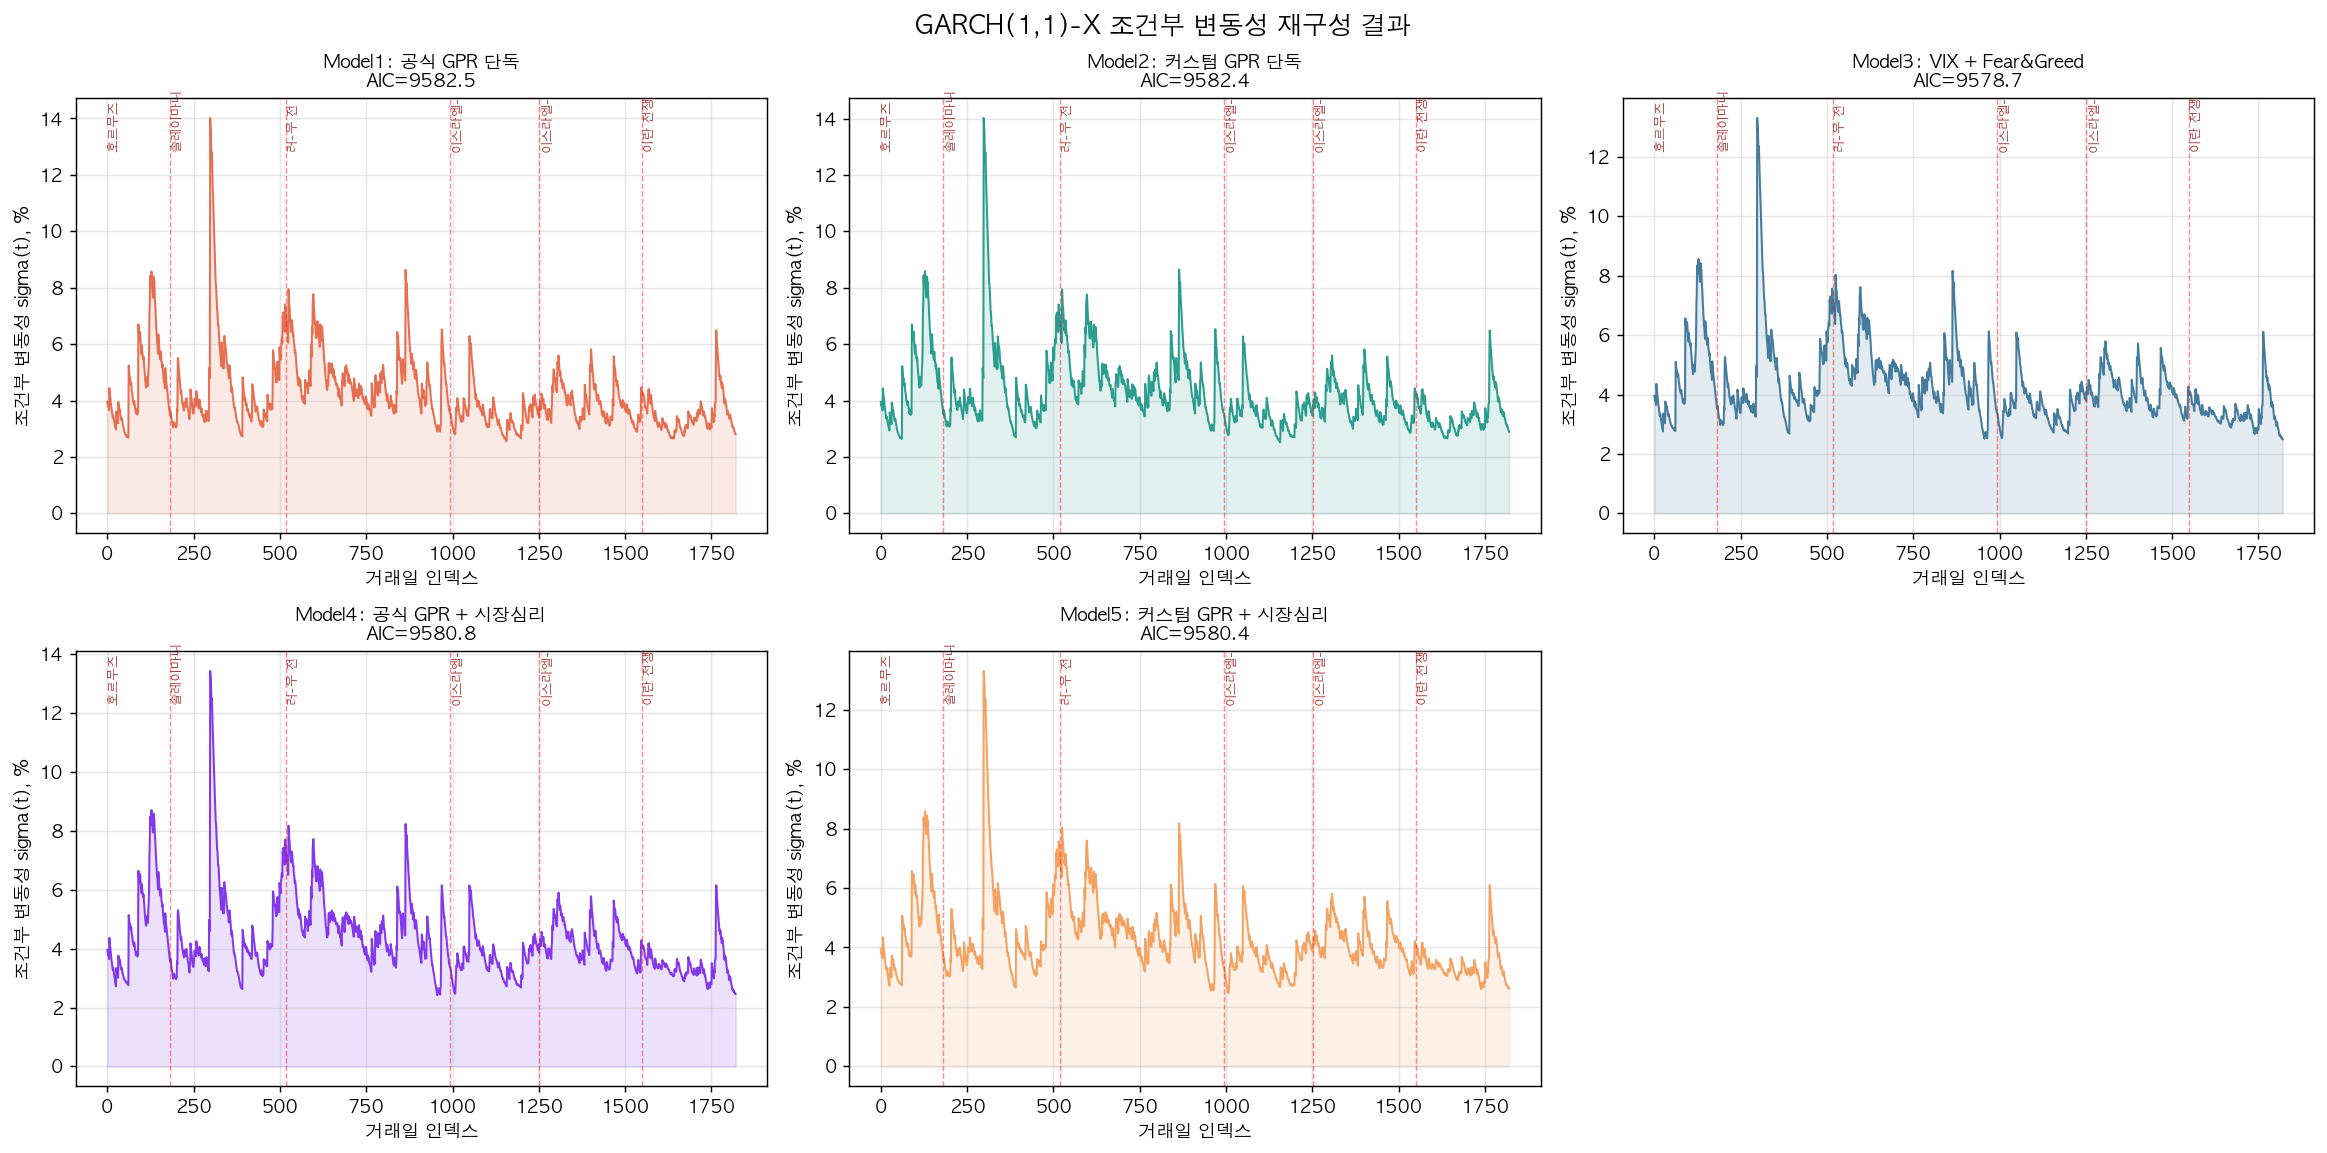

✅ 저장: /Users/minjin/cs_mj/minjin/garch_outputs/garch_conditional_vol.png


In [31]:
valid_results = [(m, r) for m, r in garch_results.items() if r.get('result') is not None and not r.get('error')]

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=False)
axes = axes.flatten()

# master_final 기준 이벤트 경계
boundaries = []
cumsum = 0
for ev in EVENT_DATES:
    n_ev = len(master_final[master_final['event_name'] == ev])
    if n_ev > 0:
        boundaries.append((cumsum, ev))
        cumsum += n_ev

for idx, (mname, res) in enumerate(valid_results):
    ax = axes[idx]
    cv = reconstruct_cond_vol(res)
    color = MODEL_COLORS.get(mname, '#555')
    ax.plot(cv, color=color, lw=1.1, label='sigma(t)')
    ax.fill_between(range(len(cv)), cv, alpha=0.15, color=color)
    for pos, ev in boundaries[1:]:
        if pos < len(cv):
            ax.axvline(pos, color='red', lw=0.8, ls='--', alpha=0.45)
    ymax = np.nanmax(cv)
    for pos, ev in boundaries:
        if pos < len(cv):
            ax.text(pos + 2, ymax * 0.92, EVENT_LABELS.get(ev, ev)[:5],
                    fontsize=7, rotation=90, color='darkred', alpha=0.8)
    ax.set_title(f'{mname}: {MODEL_LABELS[mname]}\nAIC={res["aic"]:.1f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('거래일 인덱스')
    ax.set_ylabel('조건부 변동성 sigma(t), %')
    ax.grid(alpha=0.3)

for j in range(len(valid_results), len(axes)):
    axes[j].axis('off')

plt.suptitle('GARCH(1,1)-X 조건부 변동성 재구성 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'garch_conditional_vol.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ 저장: {OUTPUT_DIR / "garch_conditional_vol.png"}')

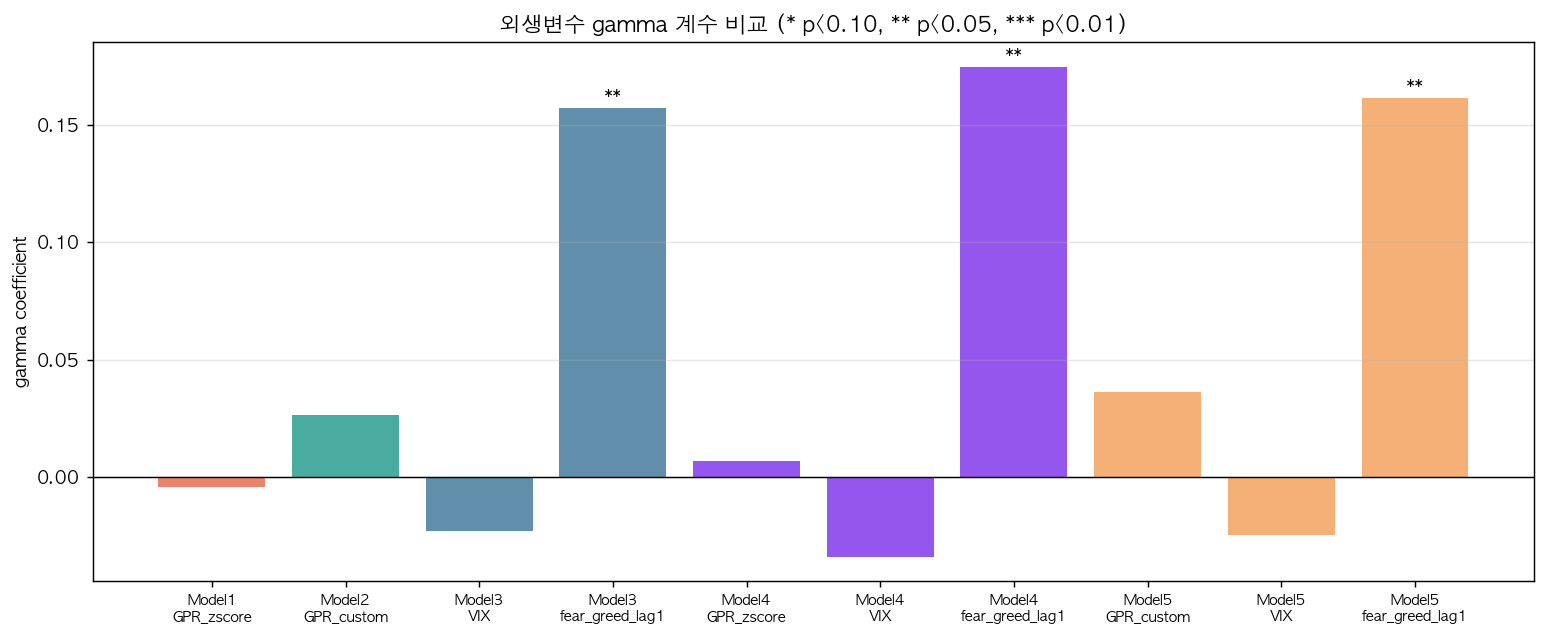

✅ 저장: /Users/minjin/cs_mj/minjin/garch_outputs/garch_gamma_coefficients.png


In [32]:
if len(gamma_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(gamma_df))
    colors = [MODEL_COLORS.get(m, '#555') for m in gamma_df['model']]
    bars = ax.bar(x, gamma_df['gamma'], color=colors, alpha=0.85)
    ax.axhline(0, color='black', lw=0.8)
    for bar, (_, row) in zip(bars, gamma_df.iterrows()):
        pv = row['p_value']
        sig = '***' if pv < 0.01 else '**' if pv < 0.05 else '*' if pv < 0.10 else ''
        ax.text(bar.get_x() + bar.get_width()/2, row['gamma'], sig,
                ha='center', va='bottom' if row['gamma'] >= 0 else 'top', fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{r.model}\n{r.variable.replace("_scaled", "")}' for r in gamma_df.itertuples()], rotation=0, fontsize=8)
    ax.set_ylabel('gamma coefficient')
    ax.set_title('외생변수 gamma 계수 비교 (* p<0.10, ** p<0.05, *** p<0.01)', fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'garch_gamma_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ 저장: {OUTPUT_DIR / "garch_gamma_coefficients.png"}')

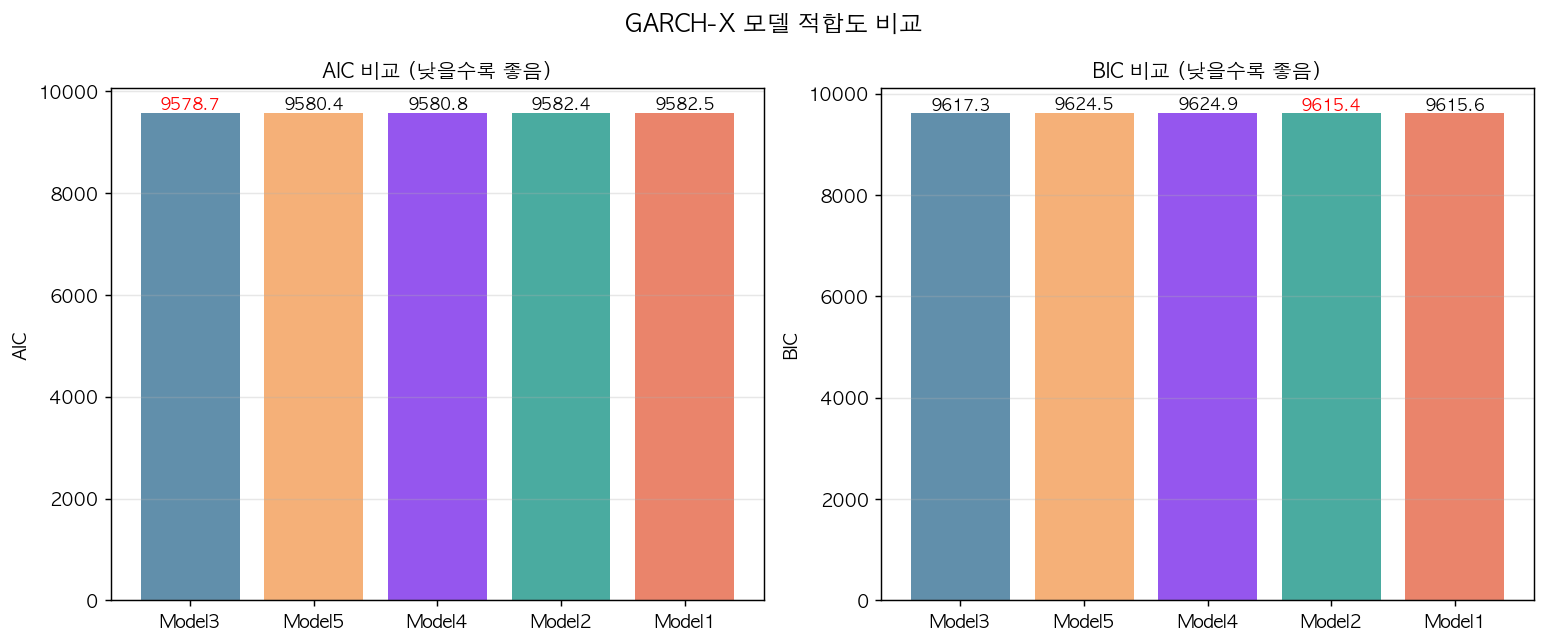

✅ 저장: /Users/minjin/cs_mj/minjin/garch_outputs/garch_model_comparison.png


In [33]:
if len(compare_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, metric in zip(axes, ['AIC', 'BIC']):
        vals = compare_df[metric].values
        labels = compare_df['model'].values
        colors = [MODEL_COLORS.get(m, '#555') for m in labels]
        bars = ax.bar(labels, vals, color=colors, alpha=0.85)
        best_val = np.nanmin(vals)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.1f}',
                    ha='center', va='bottom', fontsize=9,
                    color='red' if val == best_val else 'black')
        ax.set_title(f'{metric} 비교 (낮을수록 좋음)', fontsize=11, fontweight='bold')
        ax.set_ylabel(metric)
        ax.grid(axis='y', alpha=0.3)
    plt.suptitle('GARCH-X 모델 적합도 비교', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'garch_model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ 저장: {OUTPUT_DIR / "garch_model_comparison.png"}')

---
## 코드 설명 및 보완 가능 파트

코드 흐름

1. `DATA_PATH`
   - 수정 master data 로드

2. `exog_cols_all`
   - 표준화할 외생변수 목록

3. `MODEL_EXOG`
   - Model1~Model5 외생변수 조합

4. `fit_garch_x_model()`
   - Student-t GARCH-X 직접 MLE
   - 기본 `variance_mode='clip'`
   - Model2 multi-start 포함

5. `reconstruct_cond_vol()`
   - `.conditional_volatility` 대체
   - 추정 파라미터로 조건부 변동성 재계산

수정 가능 변수

- `MODEL_EXOG`
  - 외생변수 조합 추가/삭제

- `exog_cols_all`
  - 새 외생변수 표준화 시 같이 수정

- `start_grid`
  - Model2 초기값 추가 가능

- `garch_bounds()`
  - `omega`, `alpha`, `beta`, `nu` 제약 조정 가능

- `variance_mode`
  - 기본 `clip`
  - 강건성 `strict`

주의

- 외생변수 늘리면 파라미터 증가
- 표본 대비 복잡한 모델은 과적합 가능
- `beta=0.3` 하한 고정, `omega/gamma` 과대 추정이면 불안정 신호

---
## Step 11. 결론 해석 가이드

해석 기준

- `AIC` 최저 모델: 상대 적합도 가장 높음
- `alpha + beta`: 1에 가까울수록 변동성 지속성 큼
- `gamma(GPR_custom_scaled) > 0`: GPR_custom 상승 시 BTC 변동성 증가
- `gamma(GPR_custom_scaled) < 0`: GPR_custom 상승 시 BTC 변동성 감소

표현 주의

- 확정적 결론 X
- “시사”, “보조 근거”, “한계 고려 필요” 정도로 정리
- 표본 수 부족, 이벤트 독립성 위반 가능성 같이 언급

In [34]:
print('=' * 80)
print('GARCH 분석 최종 결론 요약')
print('=' * 80)

if len(compare_df) > 0:
    best_model = compare_df.iloc[0]['model']
    best_res = garch_results[best_model]
    print(f'\n✅ 기본 clip 기준 AIC 최적 모델: {best_model} ({MODEL_LABELS[best_model]})')
    print(f'   AIC={best_res["aic"]:.3f}, BIC={best_res["bic"]:.3f}, LogLik={best_res["loglik"]:.3f}')
    print(f'   alpha+beta={best_res["result"].x[2] + best_res["result"].x[3]:.4f}')

if 'strict_compare_df' in globals() and len(strict_compare_df) > 0:
    strict_best = strict_compare_df.iloc[0]['model']
    print(f'\n▶ strict 기준 AIC 최적 모델: {strict_best} ({MODEL_LABELS[strict_best]})')
    if len(compare_df) > 0 and strict_best != compare_df.iloc[0]['model']:
        print('   ⚠️ clip 기준과 최적 모델 다름 → 분산 처리 방식에 민감')
    else:
        print('   ✅ clip 기준과 최적 모델 동일')

print('\n▶ GPR_custom 관련 gamma 해석')
for mname in ['Model2', 'Model5']:
    res = garch_results.get(mname)
    if not res or res.get('error') or res.get('stats') is None:
        continue
    for i, pname in enumerate(res['param_names']):
        if pname == 'gamma(GPR_custom_scaled)':
            coef = res['result'].x[i]
            pv = res['stats']['p_values'][i]
            direction = '증가' if coef > 0 else '감소'
            sig = '유의' if pv < 0.05 else '10% 수준 유의' if pv < 0.10 else '비유의'
            print(f'  [{mname}] gamma={coef:+.5f}, p={pv:.4f} ({sig}) → GPR_custom 상승 시 BTC 변동성 {direction}')

print('\n▶ 정리')
print('  - 기본 결과는 clip 방식 기준')
print('  - strict 결과는 강건성 확인용')
print('  - Student-t 오차분포로 BTC fat-tail 반영')
print('  - 조건부 변동성은 reconstruct_cond_vol()로 재계산')
print('  - 최종 해석은 AIC/BIC, gamma 방향, 분산 처리 민감도 같이 확인')

GARCH 분석 최종 결론 요약

✅ 기본 clip 기준 AIC 최적 모델: Model3 (VIX + Fear&Greed)
   AIC=9578.710, BIC=9617.260, LogLik=-4782.355
   alpha+beta=0.9961

▶ strict 기준 AIC 최적 모델: Model3 (VIX + Fear&Greed)
   ✅ clip 기준과 최적 모델 동일

▶ GPR_custom 관련 gamma 해석
  [Model2] gamma=+0.02627, p=0.7346 (비유의) → GPR_custom 상승 시 BTC 변동성 증가
  [Model5] gamma=+0.03637, p=0.5962 (비유의) → GPR_custom 상승 시 BTC 변동성 증가

▶ 정리
  - 기본 결과는 clip 방식 기준
  - strict 결과는 강건성 확인용
  - Student-t 오차분포로 BTC fat-tail 반영
  - 조건부 변동성은 reconstruct_cond_vol()로 재계산
  - 최종 해석은 AIC/BIC, gamma 방향, 분산 처리 민감도 같이 확인


---
## Step 12. 결과 저장

저장 위치

```text
minjin/garch_outputs/
```

저장 파일

- `garch_model_comparison.csv`
- `garch_gamma_results.csv`
- `garch_conditional_volatility.csv`
- `garch_model_params.csv`
- `garch_conditional_vol.png`
- `garch_gamma_coefficients.png`
- `garch_model_comparison.png`

In [35]:
# 모델 비교 저장
compare_df.to_csv(OUTPUT_DIR / 'garch_model_comparison.csv', index=False, encoding='utf-8-sig')

# gamma 저장
if len(gamma_df) > 0:
    gamma_df.to_csv(OUTPUT_DIR / 'garch_gamma_results.csv', index=False, encoding='utf-8-sig')

# 전체 파라미터 저장
param_rows = []
for mname, res in garch_results.items():
    if res.get('error') or res.get('result') is None:
        continue
    pvals = res.get('stats', {}).get('p_values')
    ses = res.get('stats', {}).get('se')
    for i, pname in enumerate(res['param_names']):
        param_rows.append({
            'model': mname,
            'model_label': MODEL_LABELS.get(mname, mname),
            'param': pname,
            'estimate': res['result'].x[i],
            'se': ses[i] if ses is not None else np.nan,
            'p_value': pvals[i] if pvals is not None else np.nan,
            'converged': res['converged'],
            'loglik': res['loglik'],
            'AIC': res['aic'],
            'BIC': res['bic'],
        })
param_df = pd.DataFrame(param_rows)
param_df.to_csv(OUTPUT_DIR / 'garch_model_params.csv', index=False, encoding='utf-8-sig')

# 최적 모델 조건부 변동성 저장
if len(compare_df) > 0:
    best_model = compare_df.iloc[0]['model']
    best_res = garch_results[best_model]
    cond_vol = reconstruct_cond_vol(best_res)
    idx = best_res['y_index']
    cond_df = pd.DataFrame({
        'date': master_final.loc[idx, 'date'].values,
        'event_name': master_final.loc[idx, 'event_name'].values,
        'BTC_return_pct': master_final.loc[idx, 'returns_pct'].values,
        'best_model': best_model,
        'cond_vol': cond_vol,
    })
    cond_df.to_csv(OUTPUT_DIR / 'garch_conditional_volatility.csv', index=False, encoding='utf-8-sig')

print('▶ 저장 파일 확인')
for f in ['garch_model_comparison.csv', 'garch_gamma_results.csv',
          'garch_model_params.csv', 'garch_conditional_volatility.csv',
          'garch_conditional_vol.png', 'garch_gamma_coefficients.png',
          'garch_model_comparison.png']:
    path = OUTPUT_DIR / f
    print(f'  {"✅" if path.exists() else "❌"} {path}')

▶ 저장 파일 확인
  ✅ /Users/minjin/cs_mj/minjin/garch_outputs/garch_model_comparison.csv
  ✅ /Users/minjin/cs_mj/minjin/garch_outputs/garch_gamma_results.csv
  ✅ /Users/minjin/cs_mj/minjin/garch_outputs/garch_model_params.csv
  ✅ /Users/minjin/cs_mj/minjin/garch_outputs/garch_conditional_volatility.csv
  ✅ /Users/minjin/cs_mj/minjin/garch_outputs/garch_conditional_vol.png
  ✅ /Users/minjin/cs_mj/minjin/garch_outputs/garch_gamma_coefficients.png
  ✅ /Users/minjin/cs_mj/minjin/garch_outputs/garch_model_comparison.png
